<a href="https://colab.research.google.com/github/prvallejoz/ejercicio3-mcib-b/blob/dev_bryan/TAREA_3_GRUPO_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:

# 1. IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style="whitegrid")


In [42]:
# 2. CARGA DEL DATASET

# Cargar los datos desde la ruta indicada
data = pd.read_csv('/content/hotel_bookings.csv')

# Mostrar dimensiones y primeras 5 filas
print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [43]:
# 3. LIMPIEZA DE DATOS

# Eliminar registros duplicados

print("Dimensiones iniciales:", data.shape)
print("\nTipos de datos:")
print(data.dtypes)

Dimensiones iniciales: (119390, 32)

Tipos de datos:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type           

In [44]:
print("\nPrimeras filas:")
display(data.head())


Primeras filas:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [45]:
print("\nValores nulos por columna:")
display(data.isnull().sum().sort_values(ascending=False))


Valores nulos por columna:


,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [46]:
print("\nDuplicados exactos detectados:", data.duplicated().sum())


Duplicados exactos detectados: 31994


In [47]:
duplicados_antes = data.duplicated().sum()

data.drop_duplicates(inplace=True)

duplicados_despues = data.duplicated().sum()

print("Duplicados antes:", duplicados_antes)
print("Duplicados después:", duplicados_despues)
print("Nuevo shape:", data.shape)

Duplicados antes: 31994
Duplicados después: 0
Nuevo shape: (87396, 32)


In [48]:
# 4. ANALISÍS DE COLUMNAS

# % de nulos
null_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

diagnostico = pd.DataFrame({
    'tipo_dato': data.dtypes,
    'nulos': data.isnull().sum(),
    '%_nulos': round((data.isnull().sum()/len(data))*100,2),
    'valores_unicos': data.nunique()
})

display(diagnostico.sort_values('%_nulos', ascending=False))

,tipo_dato,nulos,%_nulos,valores_unicos
company,float64,82137,93.98,352
agent,float64,12193,13.95,333
country,object,452,0.52,177
hotel,object,0,0.00,2
arrival_date_month,object,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
lead_time,int64,0,0.00,479
is_canceled,int64,0,0.00,2
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35


In [49]:
#5. ELIMINAR COLUMNAS DE DATASET

columnas_a_borrar = ['company', 'agent', 'reservation_status', 'reservation_status_date']

data.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')

print("Columnas eliminadas correctamente.")
print("Nuevo total columnas:", data.shape[1])

Columnas eliminadas correctamente.
Nuevo total columnas: 28


In [50]:
# 6 ANALIZAR NULOS DE COLUMNAS CHILDREN Y COUNTRY

cols_null = ['children', 'country']

for col in cols_null:
    if col in data.columns:
        print(f"{col} -> nulos antes:", data[col].isnull().sum())

children -> nulos antes: 4
country -> nulos antes: 452


In [51]:
# Rellenar valores faltantes
data['children'] = data['children'].fillna(data['children'].mode()[0])
data['country'] = data['country'].fillna(data['country'].mode()[0])

In [52]:
# 7. VALIDACIÓN GENERAL DE VALORES NULOS

nulos = data.isnull().sum()
nulos_restantes = nulos[nulos > 0]

print("Columnas con nulos restantes:")
display(nulos_restantes.sort_values(ascending=False))

print("Total nulos restantes:", nulos_restantes.sum())

Columnas con nulos restantes:


,0


Total nulos restantes: 0


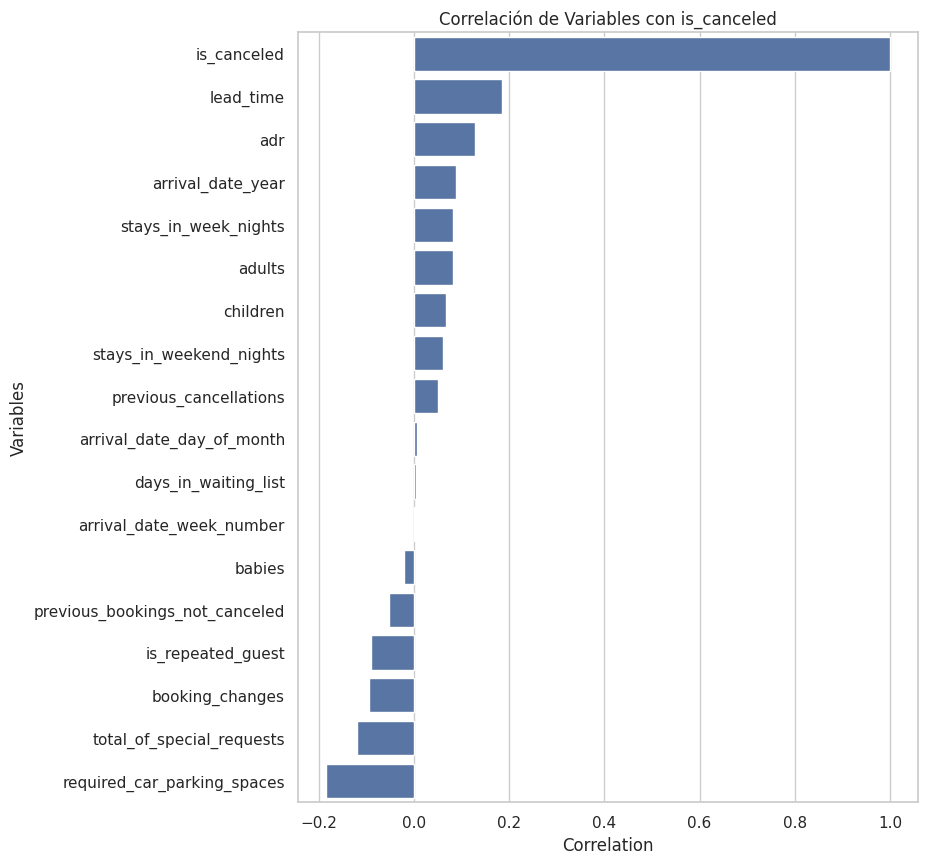

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
babies                           -0.020543
previous_bookings_not_canceled   -0.052154
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64


In [53]:

# 8. CORRELACIÓN CON LA VARIABLE TARGET
# Identificar variables mas relacionada con la cancelacion

corr_target = data.select_dtypes(include=np.number).corr()['is_canceled'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlación de Variables con is_canceled")
plt.xlabel("Correlation")
plt.ylabel("Variables")
plt.show()

print(corr_target)

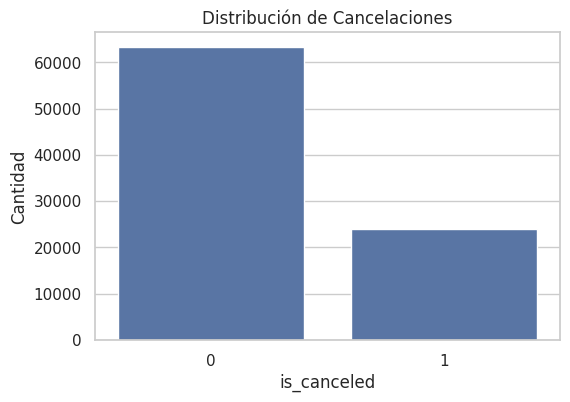

is_canceled
0    0.725102
1    0.274898
Name: proportion, dtype: float64


In [54]:
# 9. DISTRIBUCIÓN DE LA VARIABLE TARGET
# Revisar balance de clases
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=data)
plt.title("Distribución de Cancelaciones")
plt.xlabel("is_canceled")
plt.ylabel("Cantidad")
plt.show()

print(data['is_canceled'].value_counts(normalize=True))

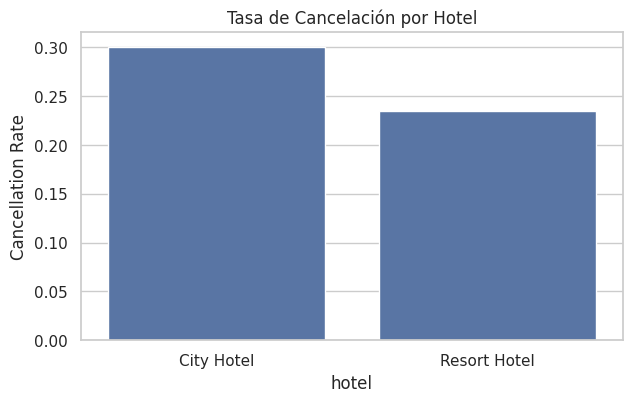

In [55]:
# 10. CANCELACIÓN POR TIPO DE HOTEL

cancel_hotel = data.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=cancel_hotel.index, y=cancel_hotel.values)
plt.title("Tasa de Cancelación por Hotel")
plt.ylabel("Cancellation Rate")
plt.show()

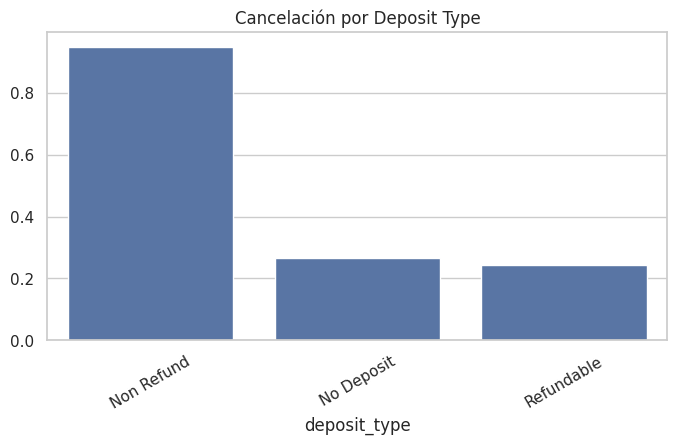

In [56]:
# 11. CANCELACIÓN POR TIPO DE DEPÓSITO

cancel_dep = data.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=cancel_dep.index, y=cancel_dep.values)
plt.title("Cancelación por Deposit Type")
plt.xticks(rotation=30)
plt.show()

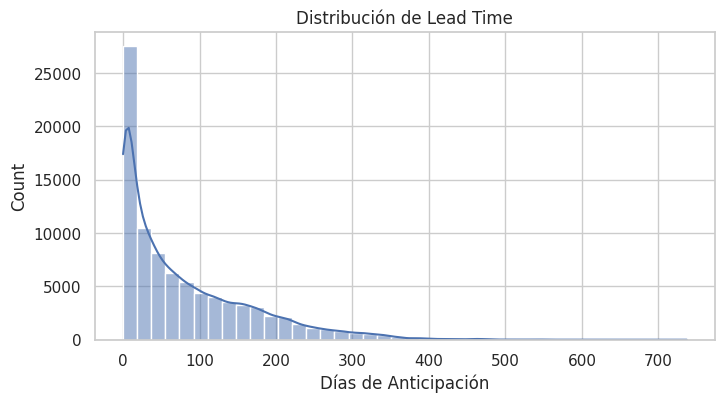

In [57]:
# 12. DISTRIBUCIÓN DE lead_time
# Ver comportamiento reservas anticipadas
plt.figure(figsize=(8,4))
sns.histplot(data['lead_time'], bins=40, kde=True)
plt.title("Distribución de Lead Time")
plt.xlabel("Días de Anticipación")
plt.show()

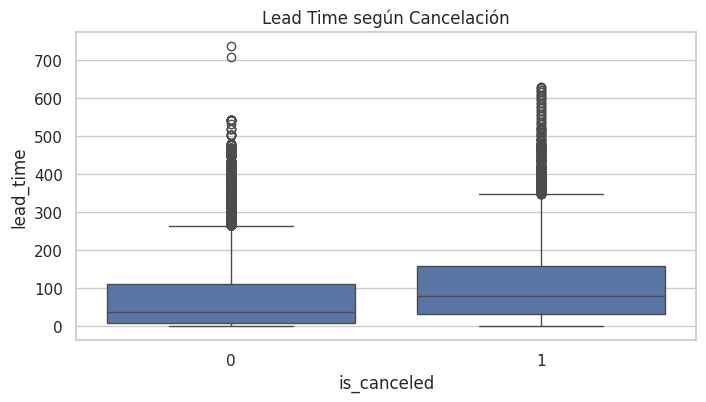

In [58]:
# 13. lead_time vs cancelación

plt.figure(figsize=(8,4))
sns.boxplot(x='is_canceled', y='lead_time', data=data)
plt.title("Lead Time según Cancelación")
plt.show()

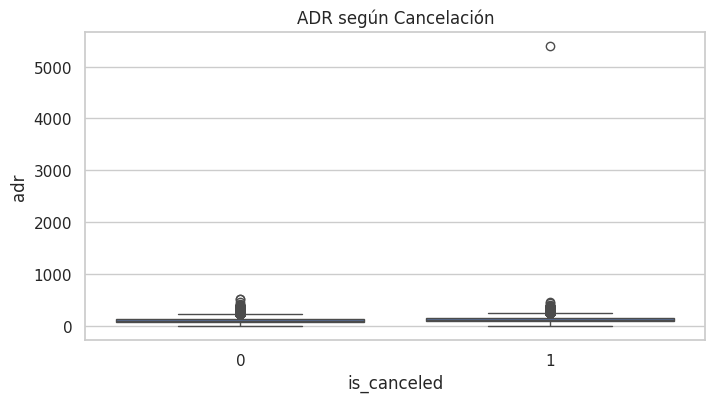

In [59]:
# 14. ADR vs cancelación
# Revisar si precio influye

plt.figure(figsize=(8,4))
sns.boxplot(x='is_canceled', y='adr', data=data)
plt.title("ADR según Cancelación")
plt.show()

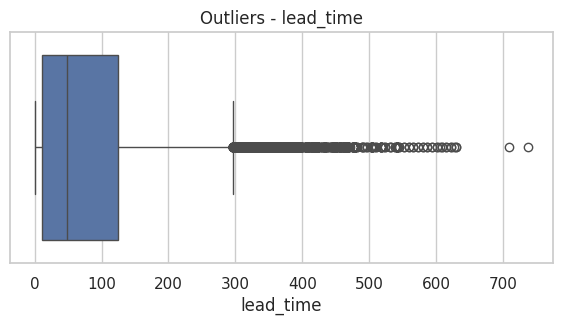

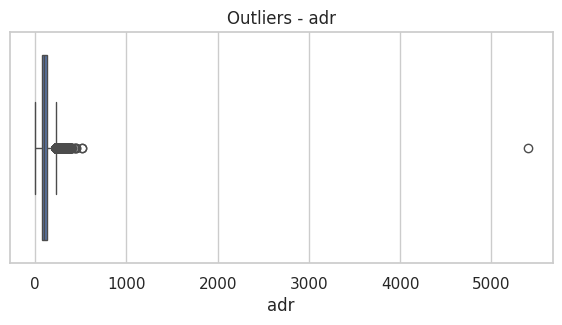

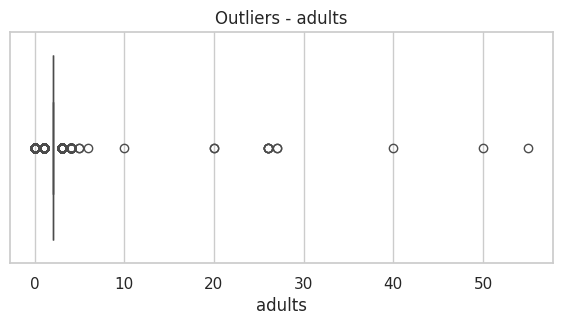

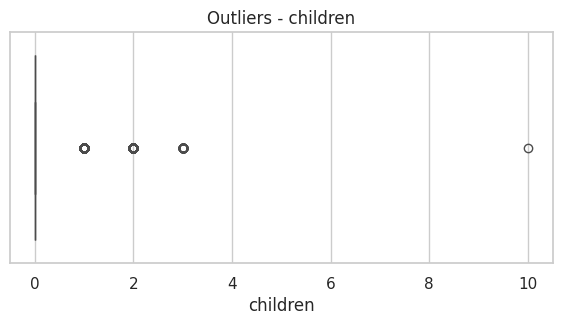

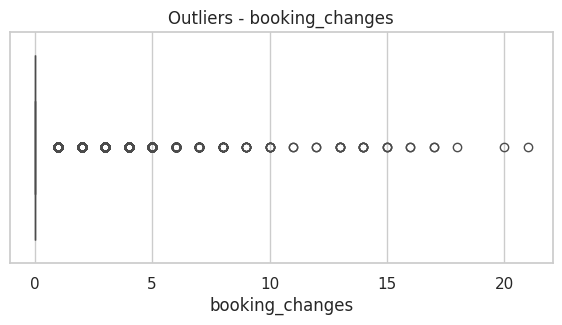

In [60]:
# 15. OUTLIERS NUMÉRICOS
# Detectar valores extremos

num_cols = ['lead_time','adr','adults','children','booking_changes']

for col in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=data[col])
    plt.title(f"Outliers - {col}")
    plt.show()

In [61]:
# 16. FEATURE ENGINEERING
# Crear nuevas variables útiles

data['total_guests'] = data['adults'] + data['children'] + data['babies']
data['total_nights'] = data['stays_in_week_nights'] + data['stays_in_weekend_nights']
data['is_family'] = ((data['children'] + data['babies']) > 0).astype(int)

print(data[['total_guests','total_nights','is_family']].head())

   total_guests  total_nights  is_family
0           2.0             0          0
1           2.0             0          0
2           1.0             1          0
3           1.0             1          0
4           2.0             2          0


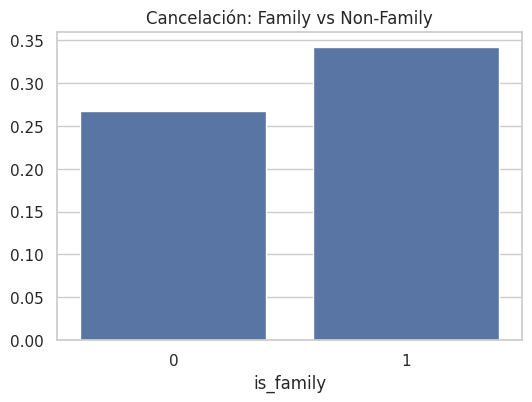

In [62]:
# 17. CANCELACIÓN POR FAMILY BOOKING

family_cancel = data.groupby('is_family')['is_canceled'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=family_cancel.index, y=family_cancel.values)
plt.title("Cancelación: Family vs Non-Family")
plt.show()

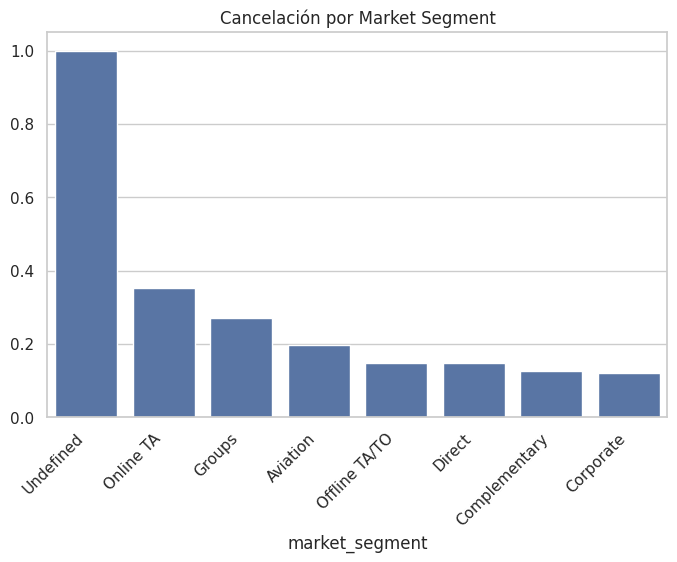

In [63]:

# 18. TOP VARIABLES CATEGÓRICAS
# Explorar market_segment

seg = data.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=seg.index, y=seg.values)
plt.xticks(rotation=45, ha='right')
plt.title("Cancelación por Market Segment")
plt.show()

In [74]:
# 19. INSIGHTS

print("Promedio cancelación:", round(data['is_canceled'].mean(),3))
print("Lead time promedio cancelados:",
      round(data[data['is_canceled']==1]['lead_time'].mean(),2))
print("Lead time promedio no cancelados:",
      round(data[data['is_canceled']==0]['lead_time'].mean(),2))

Promedio cancelación: 0.275
Lead time promedio cancelados: 105.72
Lead time promedio no cancelados: 70.1


Las reservas que terminan cancelándose fueron hechas, en promedio, con más anticipación que las reservas no canceladas.

Esto sugiere que mientras más tiempo pasa entre la reserva y la fecha de llegada, mayor puede ser la probabilidad de cancelación, posiblemente porque los clientes cambian planes, encuentran mejores opciones o modifican su viaje.

La variable lead_time parece ser un factor importante para predecir cancelaciones, por lo que se espera que tenga peso relevante en los modelos de Machine Learning.

In [65]:
# ==========================================
# BLOQUE 1. DEFINIR X e y
# Objetivo: separar variables predictoras y target
# ==========================================

X = data.drop(columns='is_canceled')
y = data['is_canceled']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87396, 30)
y shape: (87396,)


In [66]:
# ==========================================
# BLOQUE 2. IDENTIFICAR VARIABLES
# ==========================================

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", len(cat_cols))
print(cat_cols)

print("Numerical:", len(num_cols))
print(num_cols[:20])

Categorical: 10
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Numerical: 20
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'is_family']


In [67]:
# ==========================================
# BLOQUE 3. TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(69916, 30) (17480, 30)


In [68]:
# ==========================================
# BLOQUE 4. PREPROCESSING PIPELINE
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [69]:
# ==========================================
# BLOQUE 5. MODELO BASE
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'previous_bookings_not_canceled',
                                                   'booking_changes',
                                                   'days_in...
                                                   'required_car_parking_spaces',
                                                   'total_of_special_requests',
                                                   'total_guests',
                                                   'total_nights',
                                                   'is_family']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [70]:
# ==========================================
# BLOQUE 6. EVALUACIÓN LR
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix

pred_lr = lr_model.predict(X_test)

print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

[[11567  1108]
 [ 2487  2318]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.87     12675
           1       0.68      0.48      0.56      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.70      0.71     17480
weighted avg       0.78      0.79      0.78     17480



In [71]:
# ==========================================
# BLOQUE 7. RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=80,        # antes 200
        max_depth=12,           # limitar profundidad
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1              # usar todos los núcleos
    ))
])

rf_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [72]:
pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

[[12458   217]
 [ 3501  1304]]
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     12675
           1       0.86      0.27      0.41      4805

    accuracy                           0.79     17480
   macro avg       0.82      0.63      0.64     17480
weighted avg       0.80      0.79      0.74     17480



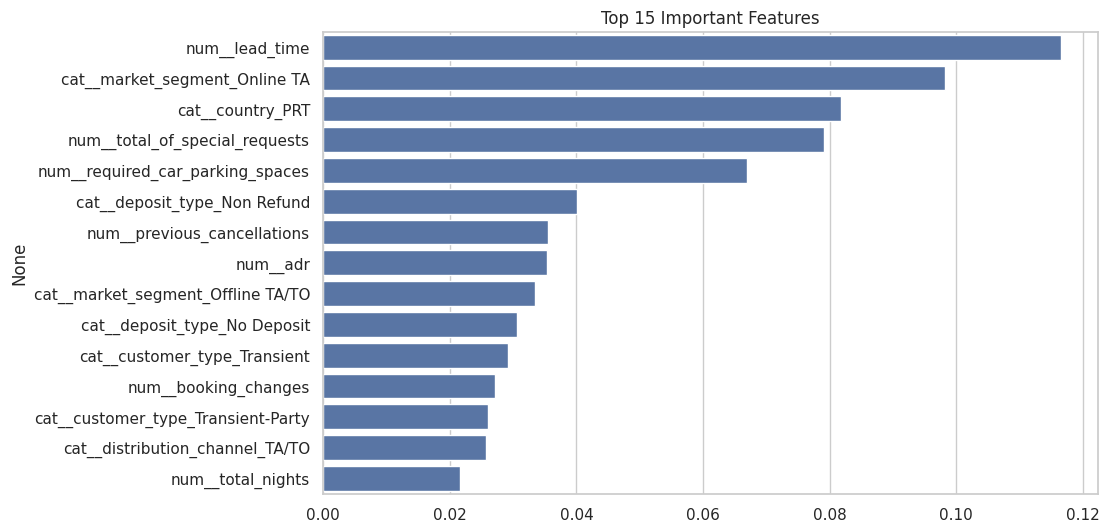

In [73]:
# Extraer modelo interno
rf_final = rf_model.named_steps['model']

# nombres columnas transformadas
feature_names = rf_model.named_steps['prep'].get_feature_names_out()

importances = pd.Series(
    rf_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Important Features")
plt.show()